# Применение теории графов для анализа связности рецензентов научного журнала

Application of graph theory to analyze the connectivity of reviewers in scientific journal

Рецензирование входящего потока рукописей -- одна из основных задач научного  журнала. В ходе рецензирования определяется пригодность к публикации. Далеко не все поступающие материалы становятся статьями на страницах издания.

В настоящей работе с помощью теории графов проводится исследование по анализу выстраивающихся связей между рецензентами в процессе экспертной оценки рукописей статей.

Код работоспособен в среде `Google Colab` на языке `R` на конец апреля 2025 года.

## Задача
1. Построить граф связей членов редакционной коллегии научного журнала.
2. Определить характеристики графа, их эволюцию (изменение по шкале), статистические распределения и предельные характеристики:
  * связности,
  * среднего пути,
  * средней степени вершин,
  * диаметра.
3. Определить остовное дерево рецензента, как совокупность его связей из графа ближних соседей, формируемого в процессе многолетней экспертной оценки статей.

## Предварительные рассуждения

### Учёт поступающих статей

В научном журнале ведётся учёт поступающих статей и назначенных на эти статьи рецензентов.

Например в исследуемом научном журнале часть таблицы учета статей приведена ниже (лишние графы таблицы исключены).

**Таблица учета статей и рецензентов**

| № пп | ... | Название |...| Рецензенты |
|------|------------|----------|---|------------|
|1|...| Повышение адекватности моделирования...|...| $\color{red}{\textbf{Иванова}}$, Соколов, Смиренкин, Тарасов|
|2 |...| Алгоритм обнаружения М-последовательностей ...|...| Портнов, Платов, Кочубейник, Алексеев,Потокаев|

Фамилии в таблице, как и названия статей вымышленные, так как не этично было упоминать фамилии истинных рецензентов в исследовании, как и те статьи что они рецензировали.


### Перевод фамилий в числа
Далее для сокращения вывода заменяем фамилии рецензентов на числа

| Фамилия | Номер   |
| --- | --- |
| $\color{red}{\textbf{Иванова}}$ | $\color{red}{\textbf{84}}$  |
| Соколов | 104  |
| Смиренкин | 57  |
| Тарасов | 106  |
| Портнов | 15  |
| Платов | 67  |
| Кочубейник | 118  |
| Алексеев | 81   |
| Потокаев | 79  |


Полученная таблица из чисел -- номеров рецензентов выглядит следующим образом

**Таблица учета статей и рецензентов (с числами вместо фамилий)**

| № пп | ... | Название |...| Рецензенты |
|------|------------|----------|---|------------|
|1|...| Повышение адекватности моделирования...|...| $\color{red}{\textbf{84}}$, 104, 57, 106|
|2 |...| Алгоритм обнаружения М-последовательностей ...|...| 15, 67, 118, 81, 79|




### О связях между рецензентами

В исследуемом научном журнале существует практика обмена рецензиями между всеми специалистами, учавствующими в экспертной оценке рукописи. Поэтому можно сказать, что в процессе рецензирования между ними выстраиваются связи. Связь в рамках одной статьи не так интересна, как складывающиеся связи между статьями.

Из первой статьи получается связи рецензентов при рецензировании рукописей
`84,104,57,106`, но для постоения графа нужны связи двух соседних вершин, а не всех сразу, поэтому возьмем все сочетания четырех вершин по две.

### Получения сочетаний

Из комбинаторики известно, что число сочетаний из $N$ по $n$ определяется из биномиального коэффициента.


$$
C_N^n=\frac{N!}{n!\cdot(N-n)!}
$$

В настоящем исследовании $n=2$, а $N$ равно количеству рецензентов на статью.

Для первой статьи из вышеприведенной таблицы статей $n=4$, $C_4^2=4!/(2!\cdot2!)=6$

Для первой статьи из таблицы сочетания будут выглядить следующим образом

In [1]:
combn(sort(as.numeric(unlist(strsplit(as.character("84,104,57,106"),split=',')))),2)

57,57,57,84,84,104
84,104,106,104,106,106


Как видно из таблицы ровно 6 сочетаний

Для второй статьи из вышеприведенной таблицы статей $n=5$, $C_5^2=5!/(2!\cdot3!)=10$ и сочетания будут выглядить следующим образом

In [2]:
combn(sort(as.numeric(unlist(strsplit(as.character("15, 67, 118, 81, 79"),split=',')))),2)

15,15,15,15,67,67,67,79,79,81
67,79,81,118,79,81,118,81,118,118


Как видно из таблицы ровно 10 сочетаний

### Визуализация полученных результатов на графе

Устанавливаем пакеты

In [3]:
install.packages("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [55]:
library(igraph,quietly = TRUE)

In [5]:
install.packages("EnvStats")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘nortest’




In [56]:
library(EnvStats,quietly = TRUE)

In [57]:
library(dplyr,quietly = TRUE)

Построим граф из полученных сочетаний первой и второй статьи и проверим их на связность

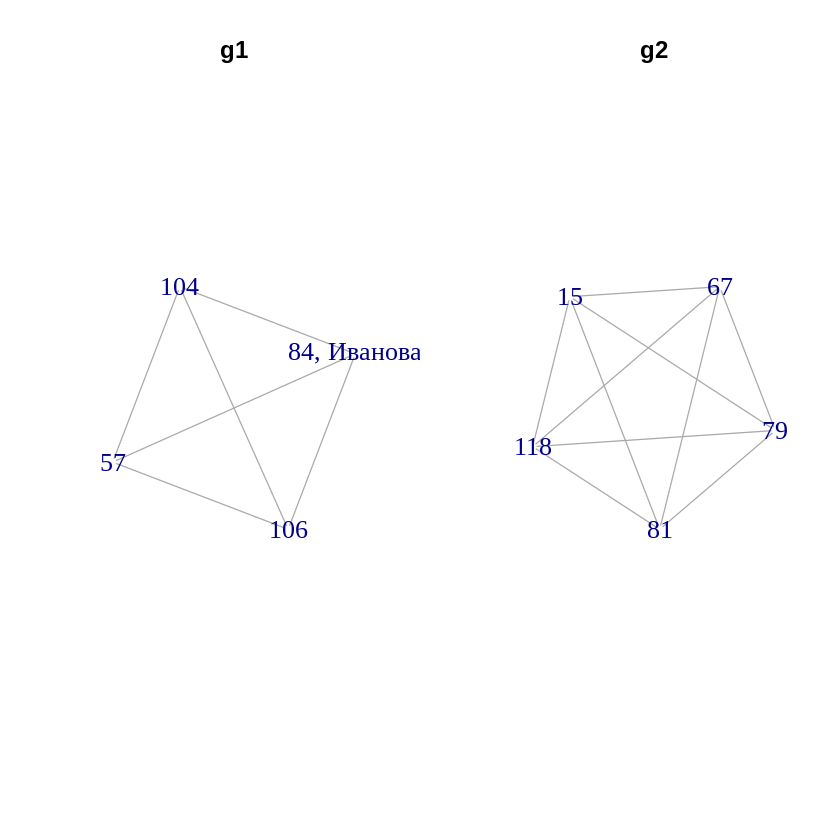

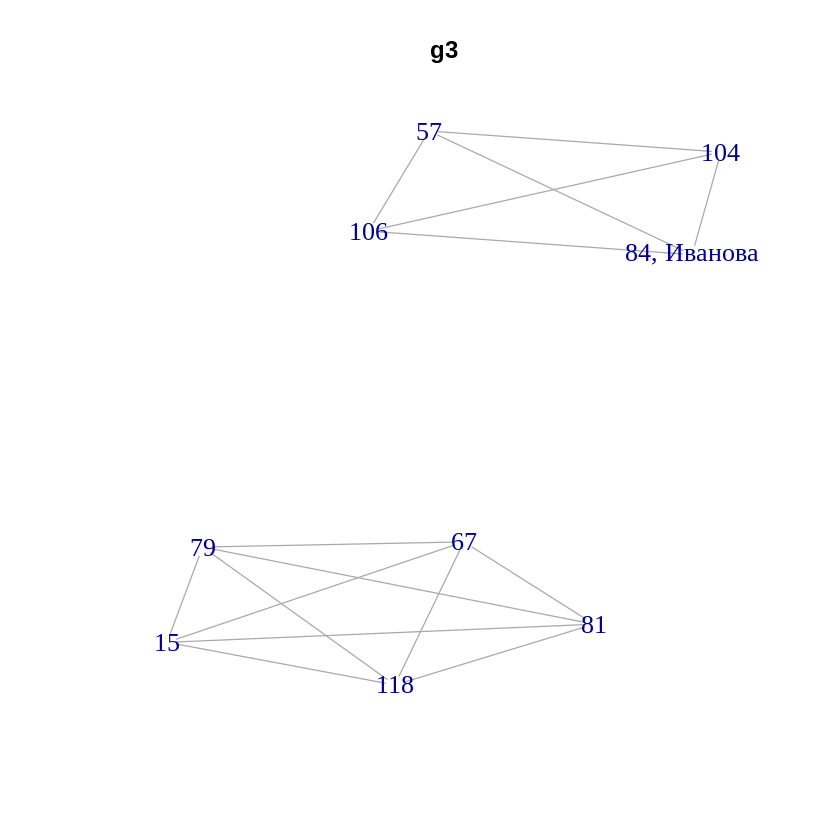

In [8]:
get_combination_ <- function(i) {
  i %>%
    as.character() %>%
    strsplit(",") %>%
    unlist() %>%
    as.numeric() %>%
    sort() %>%
    combn(m = 2) #%>%
    #t()
}

g1 <- make_graph(edges = as.vector(get_combination_("84, 104, 57, 106")), directed = FALSE)

g2 <- make_graph(edges = as.vector(get_combination_("15, 67, 118, 81, 79")), directed = FALSE)

g3 <- igraph::union(g1, g2)

g1<-delete_vertices(g1,V(g1)[degree(g1) == 0])
g2<-delete_vertices(g2,V(g2)[degree(g2) == 0])

g3<-delete_vertices(g3,V(g3)[degree(g3) == 0])


par(mfrow=c(1,2))

plot(g1,
     vertex.shape="none",
     layout = layout_with_kk(g1),
     vertex.label.cex=1.3,
     vertex.label=c("84, Иванова",104,57,106),
     vertex.label=V(g1),
     vertex.size=7,
     main="g1"
)
plot(g2,
     vertex.shape="none",
     layout = layout_with_kk(g2),
     vertex.label.cex=1.3,
     vertex.label=c(15, 67, 118, 81, 79),
     vertex.size=7,
     main="g2"
)

par(mfrow=c(1,1))

plot(g3,
     vertex.shape="none",
     layout = layout_nicely(g3),
     vertex.label.cex=1.3,
     vertex.label=c(15, 57, 79, 81, 118,106, "84, Иванова",104, 67),
     vertex.size=7,
     main="g3"
)

Связаны ли графы по отдельности?

In [9]:
is_connected(g1)
is_connected(g2)
is_connected(g3)

[1] TRUE

[1] TRUE

[1] FALSE

А являеются ли графы полными?

In [10]:
is_biconnected(g1)
is_biconnected(g2)
is_biconnected(g3)

[1] TRUE

[1] TRUE

[1] FALSE

## Реальный датасат

Теперь загрузим реальные данные по связям в редакционной коллегии научного журнала за 10 лет и выведем первые 10 записей.

Почему только за 10 лет? Потому что только с конца 2015 года в редакции начали, как правило, назначать на статью более одного реценезента

In [11]:
my_txt<-strsplit(readLines("https://raw.githubusercontent.com/denisbolshakoff/to_analyze_the_connectivity_of_reviewers/refs/heads/main/1csv.csv"),split='\n')
#my_txt<-strsplit(readLines("1csv_first.csv"),split='\n')
#my_txt<-strsplit(readLines("https://raw.githubusercontent.com/denisbolshakoff/ML-DL/refs/heads/main/Comb_for_graph_editirial_board/1csv.txt"),split='\n')
my_txt[1:10]

[[1]]
[1] "16,68"

[[2]]
[1] "68,44,16"

[[3]]
[1] "79,59,16"

[[4]]
[1] "90,8"

[[5]]
[1] "90,80,79,16,88"

[[6]]
[1] "50,16,10,115"

[[7]]
[1] "106,109"

[[8]]
[1] "79,2"

[[9]]
[1] "10,20,16"

[[10]]
[1] "16,106"

### Преобработка

Получим из реальных данных все комбинации по два и удалим из них повторы.

In [12]:
get_combination <- function(i) {
  my_txt[i] %>%
    as.character() %>%
    strsplit(",") %>%
    unlist() %>%
    as.numeric() %>%
    sort() %>%
    combn(m = 2) %>%
    t()
}

new_ <- do.call("rbind", lapply(1:length(my_txt), get_combination))

Удаляем повторы из списка данных, чтобы было ребер, которые уже появились у нас ранее

In [13]:
#new__ <- t(unique(get_combination(length(my_txt))))
new__ <- t(unique(new_))

# можно не удалять дубликаты записей, тогда общее количество
# записей в массиве увеличится, графики ниже растянуться,
# но форму свою не изменят

# ради интереса можно раскомментировать
# нижеприведенную строку и выполнить весь код с полным количеством записей
#new__ <- t(get_combination(length(my_txt)))

#строчка dim(new__)[2] должна стать примерно в два раза больше

Из количества записей

In [14]:
length(my_txt)

[1] 526

Получилось

In [15]:
dim(new__)[2]

[1] 809

Новые записи связи рецензентов в графе выглядят следующим образом

In [16]:
new__

16,16,44,16,16,59,8,16,16,16,⋯,56,56,105,32,38,7,43,43,91,69
68,44,68,59,79,79,90,80,88,90,⋯,105,118,118,127,127,80,91,130,130,107


Нетрудно заметить, что из первоначального файла

In [17]:
my_txt[1:3]

[[1]]
[1] "16,68"

[[2]]
[1] "68,44,16"

[[3]]
[1] "79,59,16"

Удалён дубликат вершины из второй записи `[16,68]`, сразу после вершины `[44,68]` идёт вершина `[16,59]`.


В дальнейшем нарастание количества используемых для построение графа ребер назовём эволюцией.

### Построение графа связей по реальным данным


Построим граф по всем полученным из датасета вершинам. Направленность графа нас не интересует, поэтому ставим свойство `directed = FALSE`.

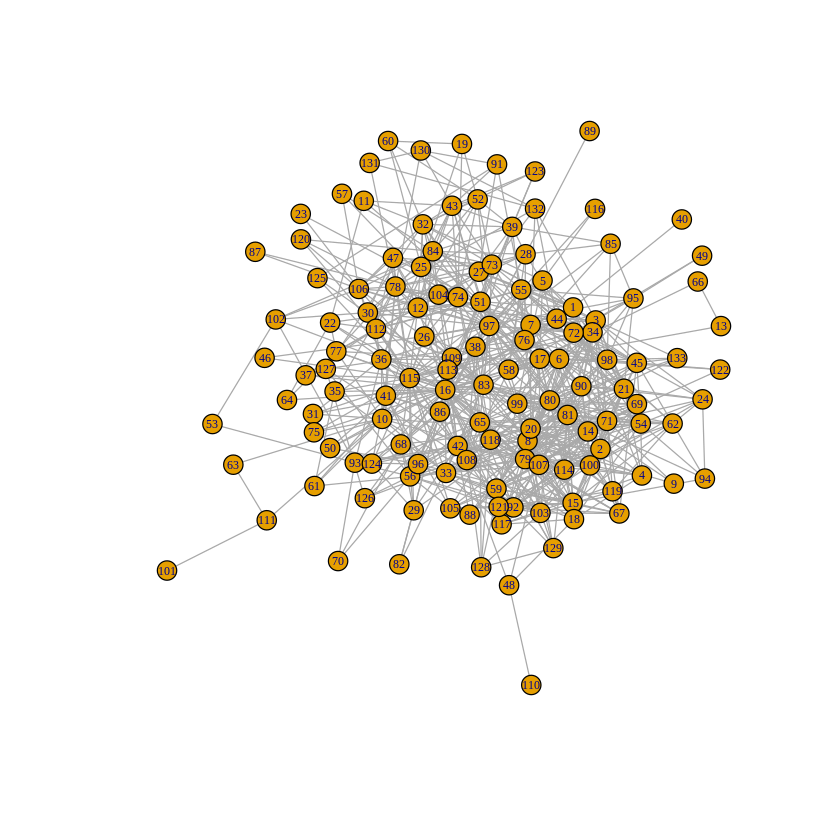

In [18]:
vertex<-length(my_txt)

g <- make_graph(edges = as.vector(new__), directed = FALSE)

# это свойство для сохранения графа в файл
#pdf()

g<-delete_vertices(g,V(g)[degree(g) == 0])


plot(g,
     layout = layout_with_kk(g),
     vertex.label.cex=0.6,
     vertex.size=7
)

# это свойство для сохранения графа в файл
#dev.off()

Граф выглядит очень кучно, как клубок ниток, и исследовать его характеристики графически сложно, поэтому воспользуемся анализом его характеристик.

### Определение характеристик графа


#### Связанность графа

In [19]:
is_connected(g)

[1] TRUE

Оказывается граф связан!

Но всегда ли граф был связанным?

Для этого проследим его эволюцию от первой вершины до последней

#### Эволюция связанности графа по появлению новых ребер

Создадим функцию, которая идёт по поступающим ребрам графа и проверяет полученные подграфы большого графа на связность

In [20]:
how_is_graph <- function(vertex){
  g <- make_graph(edges = new__[1:2,1:vertex], directed = FALSE)
  g<-delete_vertices(g,V(g)[degree(g) == 0])
  return(is_connected(g))
}

how_graph<-sapply(1:dim(new__)[2],how_is_graph)

Построим график полученной эволюции связности

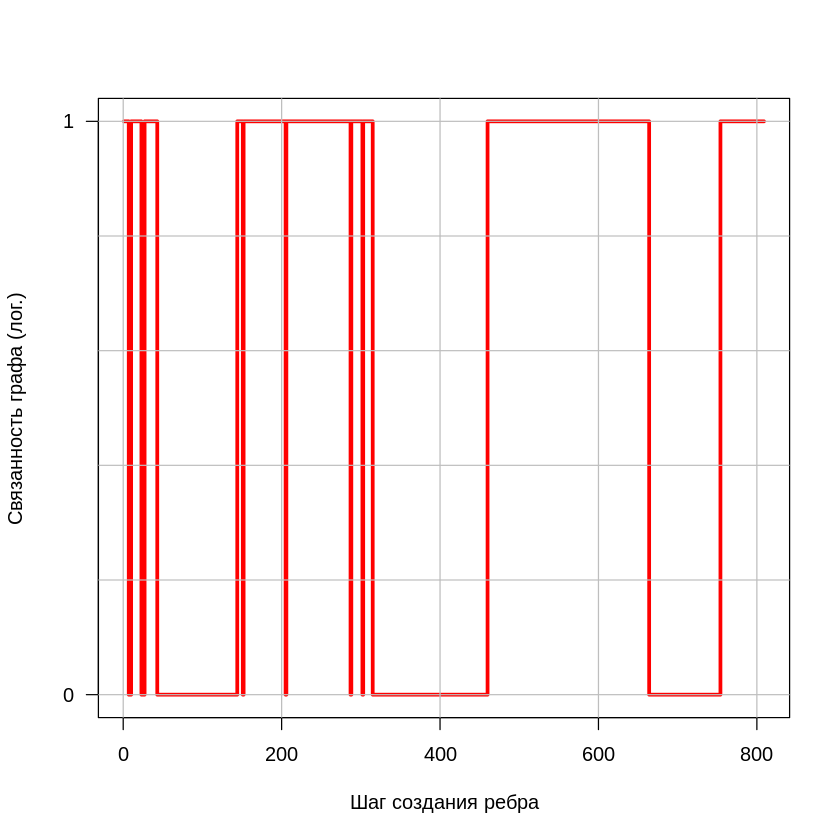

In [21]:
plot(how_graph,type='s',axes=FALSE,col="red",lwd=3,xlab = "Шаг создания ребра", ylab = "Связанность графа (лог.)")
ylabel <- seq(0, 1, by = 1)
axis(1)
axis(2, at = ylabel, las = 1)
box()
grid(lty = 1, col = "gray")

Оказывается граф очень не постоянный, и часто в периоды бывает не связным, скорее всего приведенная выше последовательность не сходится к чисто связному графу и при появлении двух новых рецензентов, у которых пока нет связи с предыдущими по рассматриваемой ими статьи вполне может быть что граф станет не связным, но в процессе работы с другими рецензентами вновь становится связным.

Но сначала оценим, а во всей эволюции граф больше связан или не связан.

In [22]:
paste(round(mean(how_graph)*100),"%")

[1] "57 %"

Всё-таки большую часть эволюции граф связан!

##### Детальное рассмотрение скачка связности графа

Рассмотрим начальный участок (как более наглядный для отображения) функции на предыдущем рисунке и попробуем понять, где появляется и кончается связность.

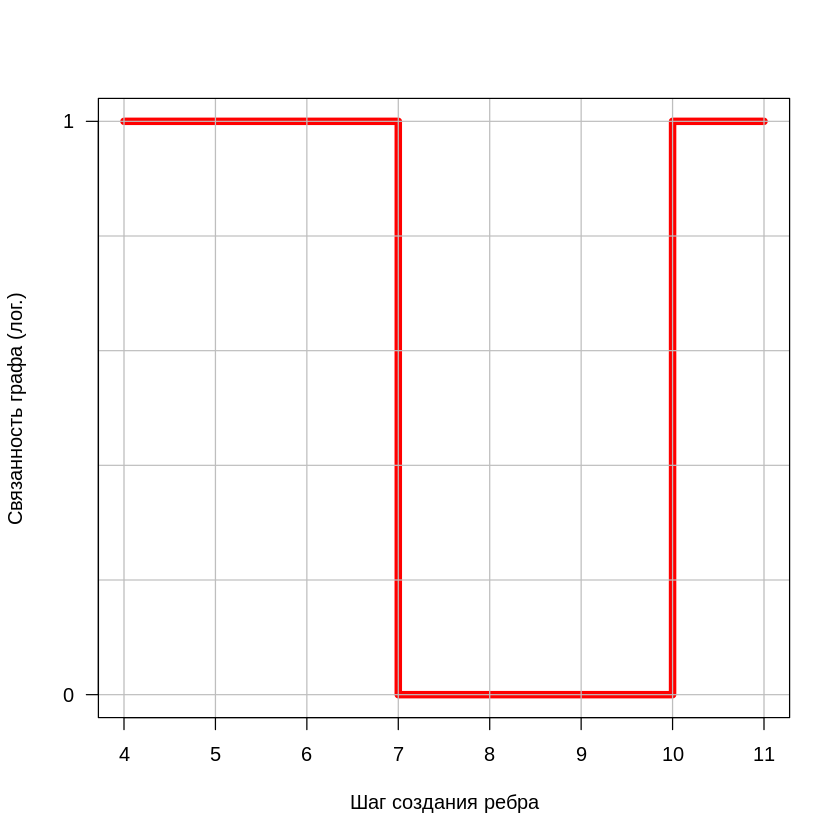

In [23]:
plot(how_graph[4:11],type='s',axes=FALSE,col="red",lwd=6,xlab = "Шаг создания ребра", ylab = "Связанность графа (лог.)")
grid(lty = 1, col = "gray")
box()

ylabel <- seq(0, 1, by = 1)
xlabel <- seq(3, 14, by = 1)

axis(1, at = seq(1, 8, by = 1), labels = 4:11)
axis(2, at = ylabel, las = 1)

Из рисунка видно, что на 6 шаге граф был связным, а после связность пропала, но снова возникла на 10 шаге. Возьмем точки 6, 7, 8, 9, 10 и 11 и построим на граф в этих точках.

In [24]:
type_of_graph <- function(x) {
  make_graph(edges = new__[1:2, 1:x], directed = FALSE) %>%
    delete_vertices(V(.)[degree(.) == 0])
}

type_graph <- sapply(1:dim(new__)[2], type_of_graph)

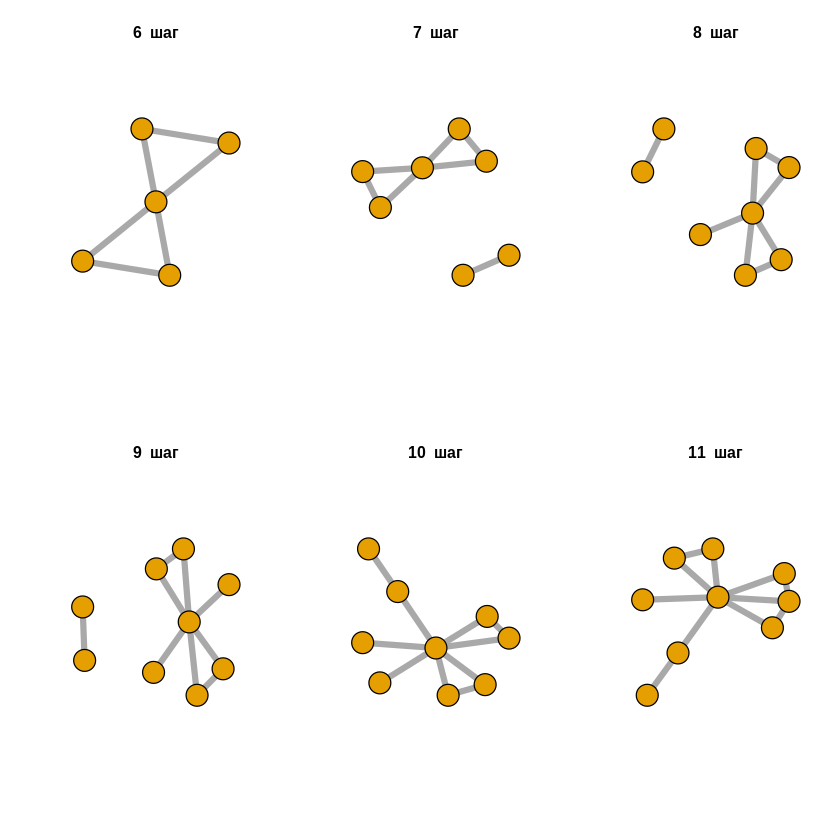

In [25]:
par(mfrow=c(2,3))

plot_graph_ <- function (x){
  plot(type_of_graph(x),vertex.size=30,vertex.label=NA,edge.width=5, main = paste(x," шаг"))
}

invisible(lapply(6:11,plot_graph_))

Как видно из рисунка выше на 6 шаге формирования граф был связный, но уже на седьмом шаге пришла статья на которую было назначено два рецензента, которые пока не имели связей с остальными.

На 7, 8 и 9 шагах связи в основном графе продолжали формироваться, пока наконец на 10 шаге две оторванных от графа вершины не соединились связью с основным графом и граф стал снова связным

Этот же факт можно проследить в исходном датасете ниже. Седьмое ребро включает две соединенные вершины `8, 90`, которые не связаны с остальными, однако уже на 10 шаге появляется ребро связывающее  вершины `16,90` и граф становится снова связным.

In [26]:
colnames(new__) <- c(1:dim(new__)[2])
print(new__[1:2,1:10])

      1  2  3  4  5  6  7  8  9 10
[1,] 16 16 44 16 16 59  8 16 16 16
[2,] 68 44 68 59 79 79 90 80 88 90


#### Эволюция диаметра графа



Но если большой граф связан, то мы можем получить его диаметр, то есть максимально возможную длину пути между всеми вершинами через функцию `diameter()`.

In [27]:
diameter(g)

[1] 6

Диаметр граф равен 6!

А это значит, что для такого социального графа, как граф связей рецензентов научного журнала выполняется гипотеза о 6 рукопожатиях ([Теория шести рукопожатий](https://www.science.org/doi/10.1126/science.1081058))


Но всегда ли было так?

Для проверки этого факта проверим формирование всех связей графа и подсчитаем диаметр получающего графа по мере увеличения количества связей.


In [28]:
diameter_of_graph <- function(x){
  return(diameter(make_graph(edges = new__[1:2,1:x], directed = FALSE)))
}

diameter_graph <- sapply(1:dim(new__)[2], diameter_of_graph)

In [29]:
# для правильного отображения легенды
#Sys.setlocale("LC_ALL", "ru_RU.UTF-8")

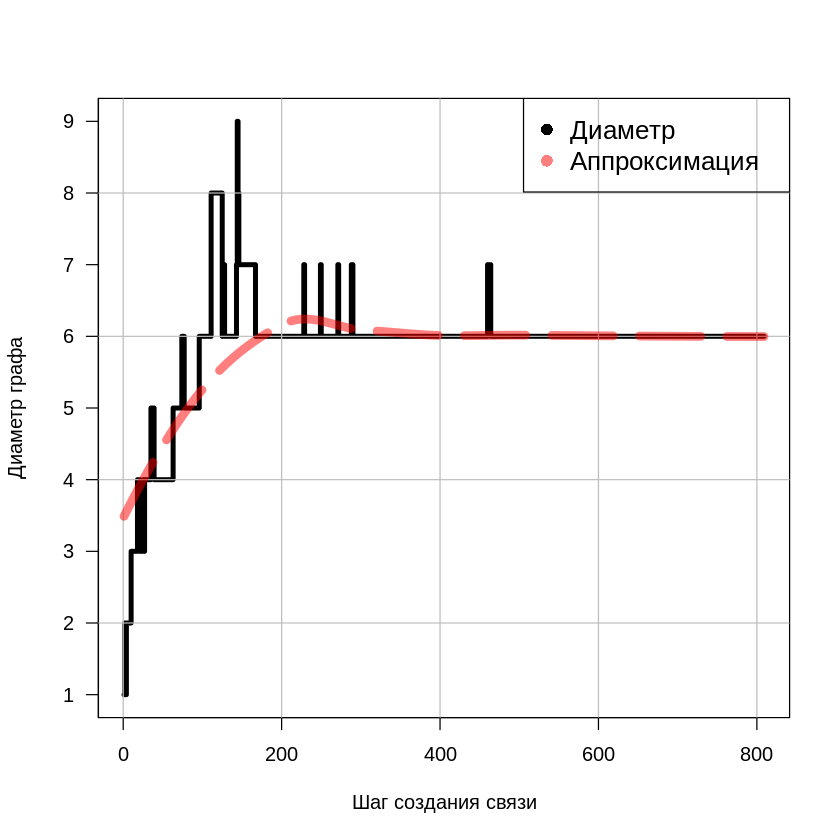

In [30]:
#plot(diameter_graph,type="l",smooth=TRUE)

lo <- loess(diameter_graph~seq(1,dim(new__)[2],1))
plot(seq(1,dim(new__)[2],1),diameter_graph, type="s",ylim = c(1, 9),xlab = "Шаг создания связи", ylab = "Диаметр графа",axes = FALSE,lwd=4)
ylabel <- seq(0, 13, by = 1)
axis(1)
axis(2, at = ylabel, las = 1)
box()
grid(lty = 1, col = "gray")
lines(predict(lo), col=rgb(1,0,0,0.5), lwd=7, lty = 5)
legend("topright",  c("Диаметр","Аппроксимация               "), bg = par("bg"),cex=1.3,box.lwd=1,col=c("black",rgb(1,0,0,0.5)),pch=c(16,16))

Зависимость диаметра графа от увеличения связей крайне интересна и напоминает квантовые скачки с уровня на уровень. Однако, как видно из графика процесс не колеблется уже после 500 шага и сходится к числу 6, что подтверждает гипотезу шести рукопожатий.

#### Эволюция среднего пути

Помимо диаметра графа интересно проследить как эволюционировал средний путь при увеличении ребер в графе

In [31]:
evolution_of_degree <- function(vertex) {
  make_graph(edges = new__[1:2, 1:vertex], directed = FALSE) %>%
    delete_vertices(V(.)[degree(.) == 0]) %>%
    distances() %>%
    {mean(.[nrow(.) * (2 * col(.) - 1) / (2 * ncol(.)) - row(.) < -1/2])}
}

evolution_of_degree_ <- sapply(1:dim(new__)[2],evolution_of_degree)

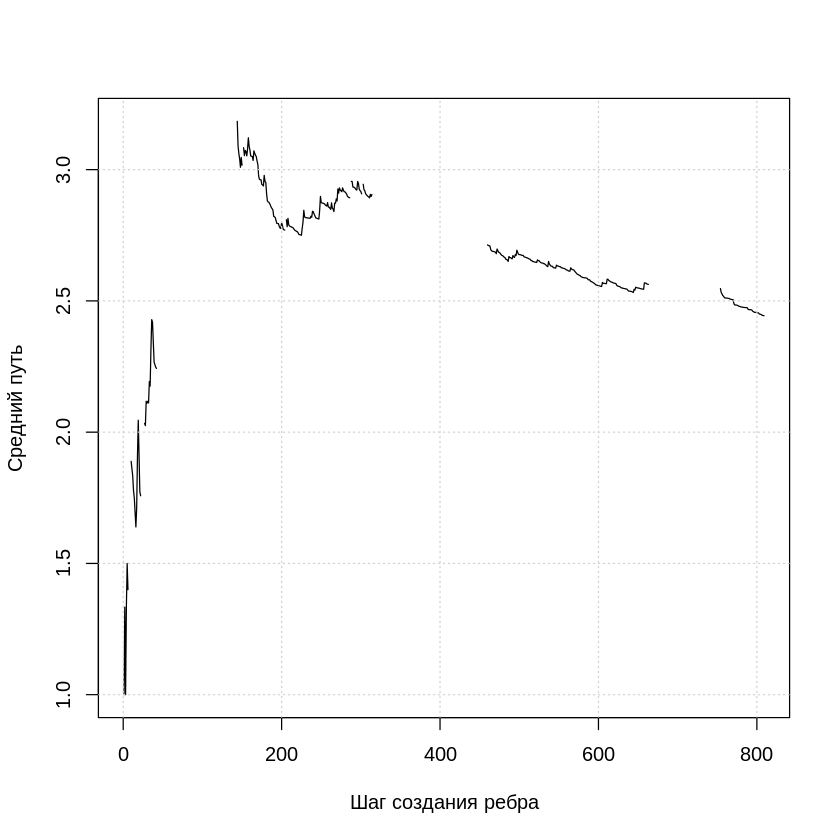

In [32]:
plot(evolution_of_degree_,type="l",xlab = "Шаг создания ребра", ylab = "Средний путь")
grid()

Сначала не понятно, что с графиком?

Однако стоит на этот график наложить ранее полученный график связанности графа как всё встает на свои места

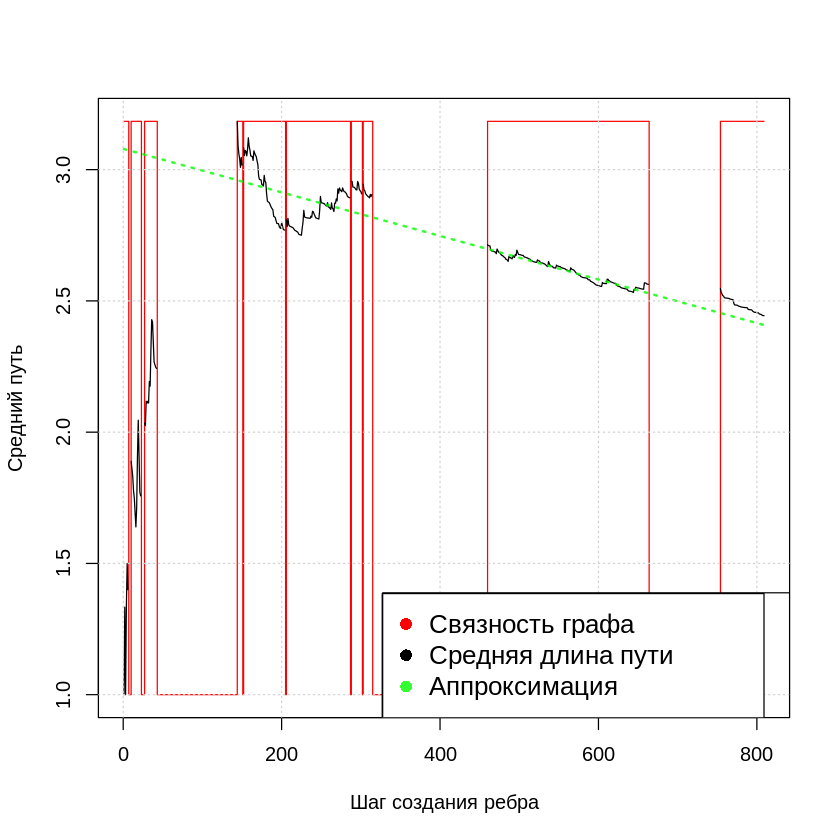

In [33]:
linear_model <- lm(evolution_of_degree_[460:663] ~ seq(460,663,1))

plot(how_graph,type='s',col="red",lwd=1, axes=FALSE, xlab = "", ylab = "")
par(new=TRUE)
plot(evolution_of_degree_,type="l", xlab = "Шаг создания ребра", ylab = "Средний путь")
lines(seq(1,dim(new__)[2],1)*linear_model$coefficients[2]+linear_model$coefficients[1], type = "l",col=rgb(0,1,0,0.8),lty = 3,lwd=2)
grid()
polygon(c(327,327,dim(new__)[2],dim(new__)[2]), c(0.9,1.385,1.385,0.9), col="white")
legend("bottomright",
       c("Связность графа","Средняя длина пути                             ","Аппроксимация               "),
       bg = par("bg"),
       cex=1.3,
       box.lwd=1,
       col=c("red","black",rgb(0,1,0,0.8)),
       pch=c(16,16,16),
       #bty="o",
       #box.col = "white",
       #fill=c("gray", "red", "gray"),
       #density=c(NA, 10, NA),
       )

Для не связного графа нельзя рассчитать среднюю длину пути.

По графику можно сказать, что в целом средняя величина пути убывает. Предельное значение равное 1 будет для полного графа, когда путь от любой вершин до любой другой будет равен единице, что означает что каждый рецензент связан с каждым при рецензировании статей.

В целом можно найти точку пересечения линейной аппроксимации и оси абсцисс, проходящей через 1.

In [34]:
paste(round(which(seq(1,10000,1)*linear_model$coefficients[2]+linear_model$coefficients[1] <= 0)[1]/dim(new__)[2]*10)," лет")

[1] "46  лет"

Если тенденция сохраниться, граф станет полным через 46 лет!

#### Распределение длин путей

Знание распределения длин путей в графе позволит более точно сказать выполняется ли статистически гипотеза о шести рукопожатиях.

Построим гистограммы распределений длин путей в графе.

Однако матрица путей в графе квадратная и для неориентировнного графа включает в себя путь в вершину 1 из вершины 2 и путь в вершину 2 из вершины 1 если между есть путь. Чтобы не считать пути дважды возьмем только верхнетреугольную матрицу

In [35]:
distances(g)[1:3,1:10]

0,2,2,1,1,2,1,2,2,2
2,0,1,2,3,2,1,1,2,2
2,1,0,2,3,2,1,2,2,2


Исключим также элементы на главной диагонали, которые показывают что путь из вершины в неё саму есть ноль.

Поэтому далее при расчётах среднего и дисперсии среднего пути будет использовать только верхнетреугольную матрицу.

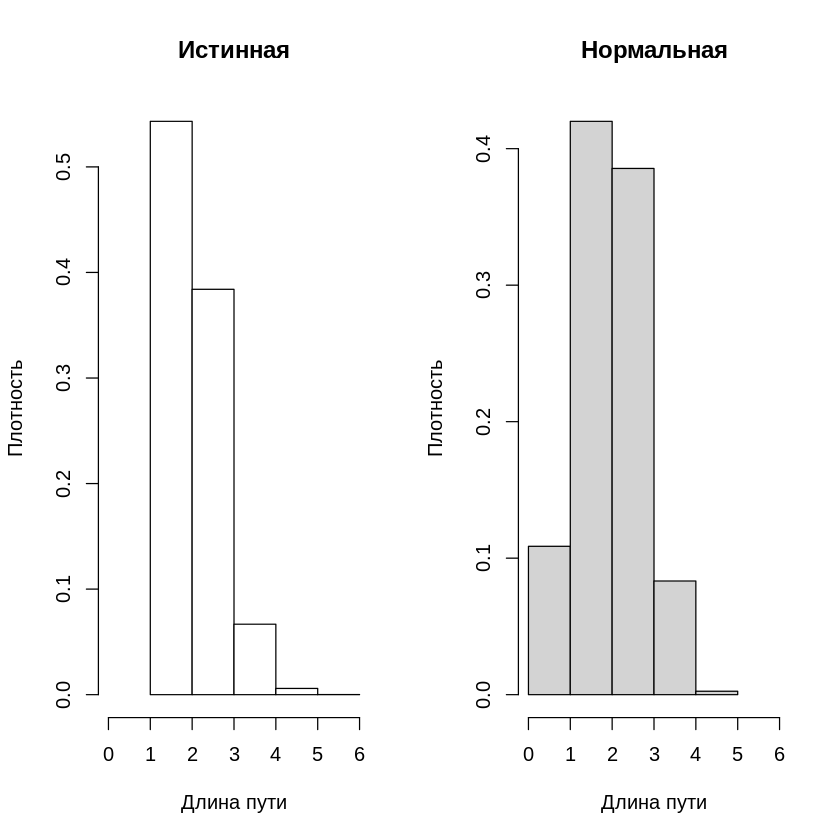

In [36]:
par(mfrow = c(1, 2))

#pp1 <- distances(g)[nrow(distances(g)) * (2 * col(distances(g)) - 1) / (2 * ncol(distances(g))) - row(distances(g)) < -1/2]

pp1<- g %>%
      distances() %>%
      {.[nrow(.) * (2 * col(.) - 1) / (2 * ncol(.)) - row(.) < -1/2]}


p1 <- hist(pp1, prob = TRUE, col = "white",breaks = 6,xlim = range(c(0:6)),freq = FALSE, xlab = "Длина пути", ylab = "Плотность", main = "Истинная")

#SD <- sqrt(var(distances(g)[nrow(distances(g)) * (2 * col(distances(g)) - 1) / (2 * ncol(distances(g))) - row(distances(g)) < -1/2]))

SD <- g %>%
      distances() %>%
      {.[nrow(.) * (2 * col(.) - 1) / (2 * ncol(.)) - row(.) < -1/2]} %>%
      var %>%
      sqrt


mean_ <- g %>%
      distances() %>%
      {.[nrow(.) * (2 * col(.) - 1) / (2 * ncol(.)) - row(.) < -1/2]} %>%
      mean

#mean_ <- mean(distances(g)[nrow(distances(g)) * (2 * col(distances(g)) - 1) / (2 * ncol(distances(g))) - row(distances(g)) < -1/2])

pp2 <- round(rnorm(length(pp1),mean_,SD))
p2 <- hist(pp2,breaks = 6,xlim = range(c(0:6)),freq = FALSE,xlab = "Длина пути", ylab = "Плотность", main = "Нормальная")


Комментарии тут излишни. Распределение нормальное, слева истинное справа нормальное, построенное по математическому ожиданию и дисперсии, оцененной по истинному распределению.

Но на всякий случай проверим гипотезы по трём тестам: Вилкоксона, Хи-квадрат и Краскала при уровне значимости $0.05$

In [37]:
wilcox.test(pp1,pp2)[3]>0.05
chisq.test(pp1,pp2,simulate.p.value = TRUE)[3]>0.05
kruskal.test(pp1,pp2)[3]>0.05

p.value 
   TRUE

p.value 
   TRUE

p.value 
   TRUE

Как и ожидалось тесты истинны, что позволяет нам утверждать, что распределение длин путей в графе имеет нормальный закон.

Для сравнения гистограмм изобразил полученные зависимости на одном графике.

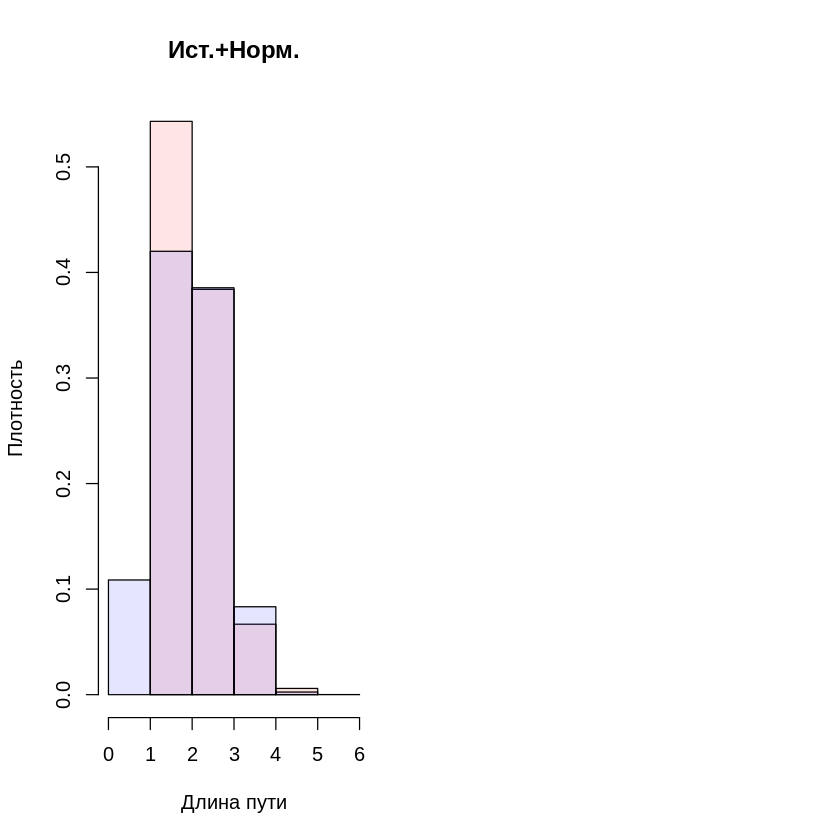

In [38]:
par(mfrow = c(1, 2))

hist(pp1,
     col=rgb(1,0,0,0.1),breaks = 6,xlim = range(c(0:6)),freq = FALSE,xlab = "Длина пути", ylab = "Плотность", main = "Ист.+Норм.")
hist(pp2,
     col=rgb(0,0,1,0.1),
     rob = TRUE,breaks = 6,xlim = range(c(0:6)),
     add=TRUE,
     freq = FALSE)


#### Эволюция средней степени вершины

Среднюю степень вершины в графе можно оценить, взяв среднее всех степеней вершин

In [39]:
round(mean(degree(g)))

[1] 12

А это означает, что рецензент в среднем создает 12 связей при работе с коллегами в редакционной коллегии.

Но всегда ли было именно 12 связей в графе?

Для этого проверим как изменялось среднее значение связей в графе при увеличении числа связей между рецензентами

In [40]:
degree_graph <- function(x){
  return(mean(degree(make_graph(edges = new__[1:2,1:x], directed = FALSE))))
}

increace_graph_degree <- sapply(1:dim(new__)[2], degree_graph)

linear_model <- lm(sapply(1:dim(new__)[2], degree_graph) ~ seq(1,dim(new__)[2],1))

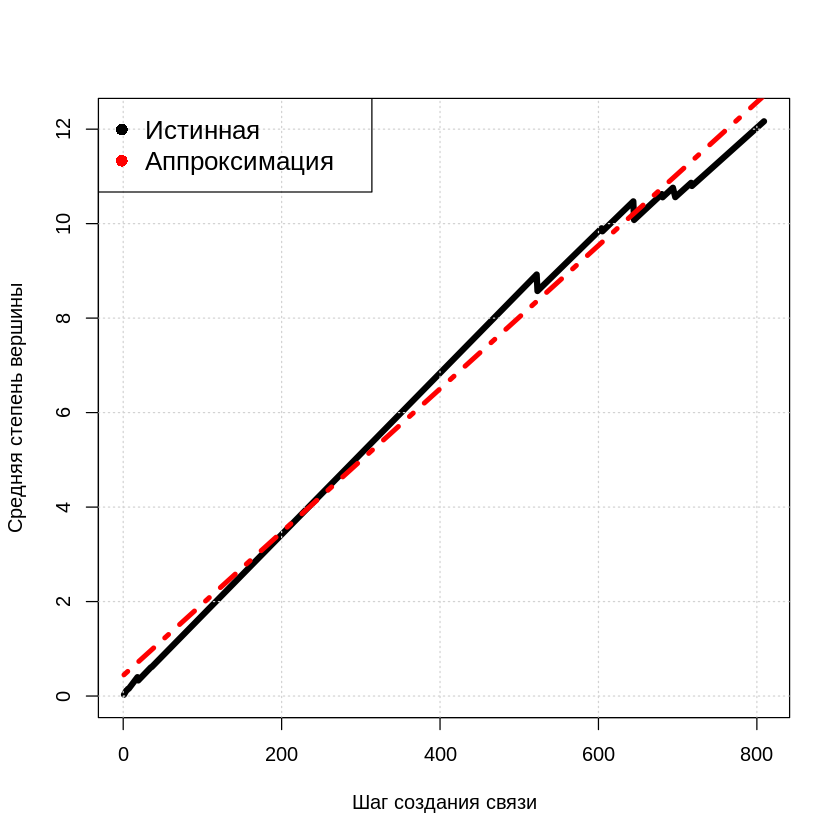

In [41]:
plot(increace_graph_degree, type = "l",ylab = "Средняя степень вершины", xlab = "Шаг создания связи",lty=1, lwd=5)
grid()
lines(seq(1,dim(new__)[2],1)*linear_model$coefficients[2]+linear_model$coefficients[1], type = "l",col="red",lty = 4,lwd=4)
legend("topleft",  c("Истинная","Аппроксимация                "),cex=1.3,col=c("black","red"),pch=c(16,16))

Как видно из рисунка среднее количество связей линейно возрастатает при увеличении числа связей между рецензентами в редакционной коллегии. Но может ли быть рост вечным?

#### Оценка предельного роста степени вершин графа

Из теории графов известно, что максимальное количество связей может быть только у полного графа и оно равно уменьшенному на один количеству вершин.

Попробуем оценить как росло количество вершин в графе при увеличении количества связей.

In [42]:
count_vertex_graph <- function(x){
  return(length(V(make_graph(edges = new__[1:2,1:x], directed = FALSE))))
}

function_diameter_graph <- sapply(1:dim(new__)[2], count_vertex_graph)

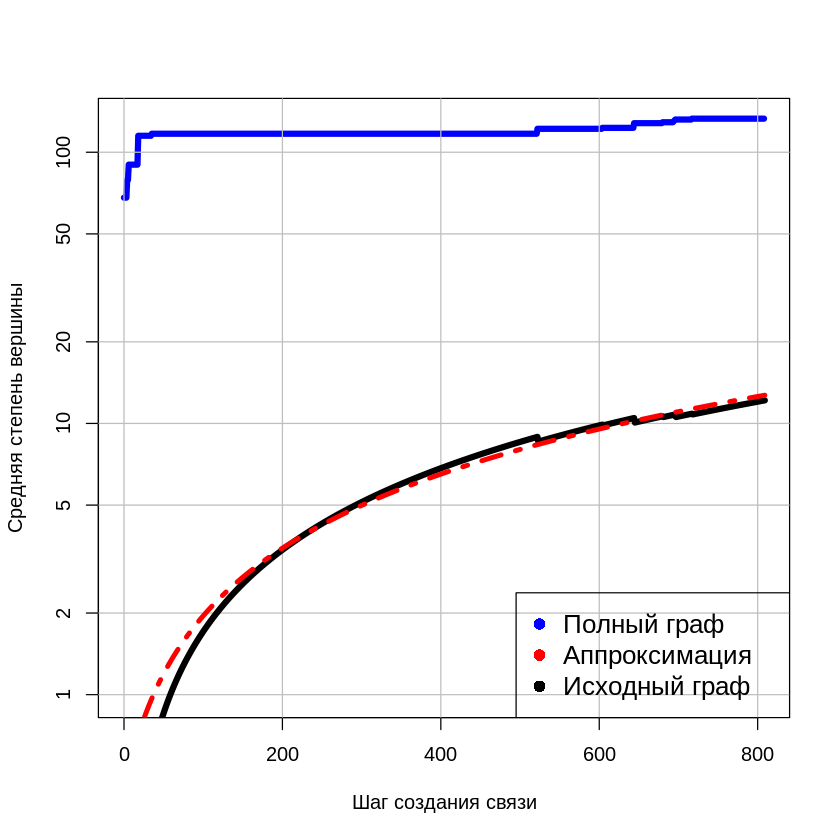

In [43]:
plot( seq(1,dim(new__)[2],1)-1,function_diameter_graph, col=rgb(0,0,1),ylim = c(1, 130),log = "y",type="l",lwd=5,ylab = "Средняя степень вершины", xlab = "Шаг создания связи")
grid(lty = 1, col = "gray",equilogs =FALSE)
lines(seq(1,dim(new__)[2],1),increace_graph_degree,lty=1, lwd=5)
lines(seq(1,dim(new__)[2],1),seq(1,dim(new__)[2],1)*linear_model$coefficients[2]+linear_model$coefficients[1],type = "l",col="red",lty = 4,lwd=4)
legend("bottomright",  c("Полный граф                  ","Аппроксимация","Исходный граф"),cex=1.3,col=c("blue","red","black"),pch=c(16,16))

Из графика видно, что среднее количество связей логарифмически стремится к полному графу (с логарифмической шкалой по оси ординат), но скорее всего никогда не достигнет этого значения, а среднее количество формируемых связей остается примерно на порядок меньше такого же количества связей в полном графе.

### Оценка пользы рецензента

Встает резонный вопрос, а есть ли какая-то граница снизу, где рецензент не приносит пользу редакционной коллегии. Ответ `0` связей отбрасываем как очевидный. Для этого построим гистограмму распределения количества связей членов редакционной коллегии.

In [44]:
sort(degree(g))

[1]  1  1  1  1  2  2  2  2  2  2  2  2  2  3  3  3  3  3  3  3  3  3  3  3  4
 [26]  4  4  4  4  4  4  4  4  4  5  5  5  5  5  5  5  6  6  6  7  7  7  8  8  8
 [51]  9  9  9  9  9  9  9 10 10 10 10 10 10 10 10 10 10 11 11 11 12 12 12 12 12
 [76] 12 13 13 13 13 13 13 14 14 14 14 14 14 14 15 15 15 16 16 16 16 16 17 17 17
[101] 17 18 18 18 18 18 19 19 19 19 20 20 20 20 21 21 21 21 22 23 23 24 26 27 27
[126] 29 31 32 32 33 36 43 50

Как видно из отсортированного списка степеней вершин есть 4 рецензента, у которых степень то есть связь с другими рецензентами только одна. Приведём этих реценезнтов на граф-схемах

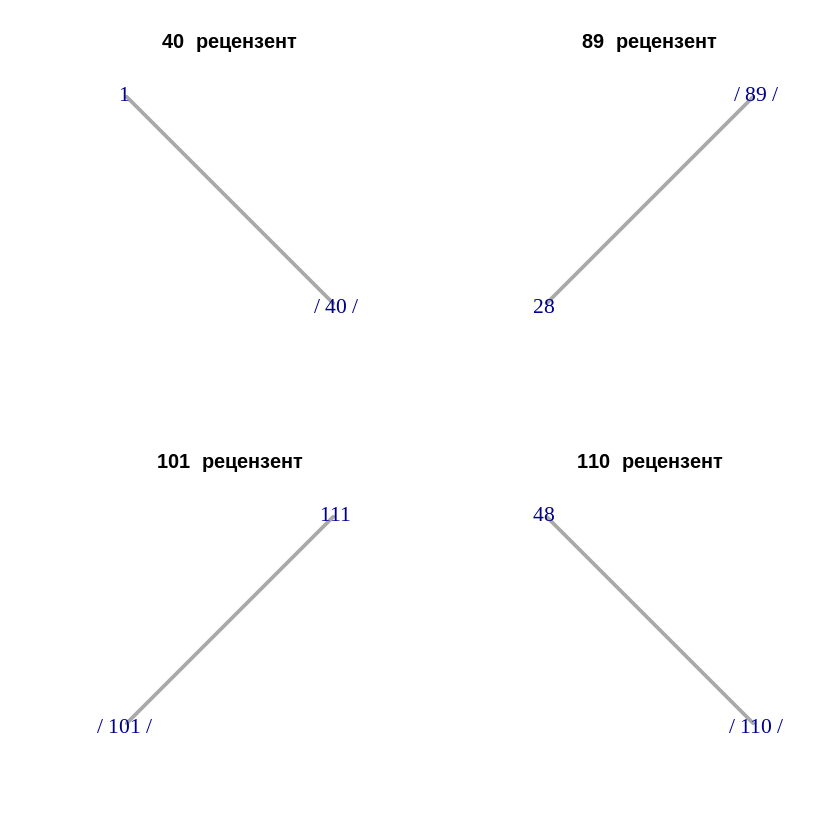

In [45]:
par(mfrow=c(2,2))

spanning_tree_graph <- function(vertex)
{

# Выбираем интересующую вершину
vertex_of_interest <- vertex

# Получение списка соседних вершин
neighbors_list <- neighbors(g, vertex)

# Формируем полный набор вершин для подграфа
vertices_to_include <- c(vertex_of_interest, neighbors_list)

# Построение подграфа
subgraph <- induced_subgraph(g, vids = vertices_to_include)

# Отображение подграфа
plot(mst(subgraph),
     graph = "nsca",
     vertex.shape="none",
     layout = layout_nicely(mst(subgraph)),
     vertex.label.cex=1.3,
     vertex.label=c(paste("/",vertex,"/"),neighbors_list),
     vertex.size=7,
     edge.width=3,
     main = paste(vertex," рецензент"))
}


invisible(lapply(c(V(g)[degree(g) == 1]),spanning_tree_graph))

Если вдруг всё-таки придется от них отказаться как сделать так чтобы обосновать это научно?

На помощь приходит статистика.

#### Статистическая оценка полезности рецензента

Пусть уровень значимости будет $0.05$, тогда можно найти такое количество связей $N$, которое в функции распреления будет меньше этого $N$. Для этого построим гистограммы распределений и посмотрим на их законы.

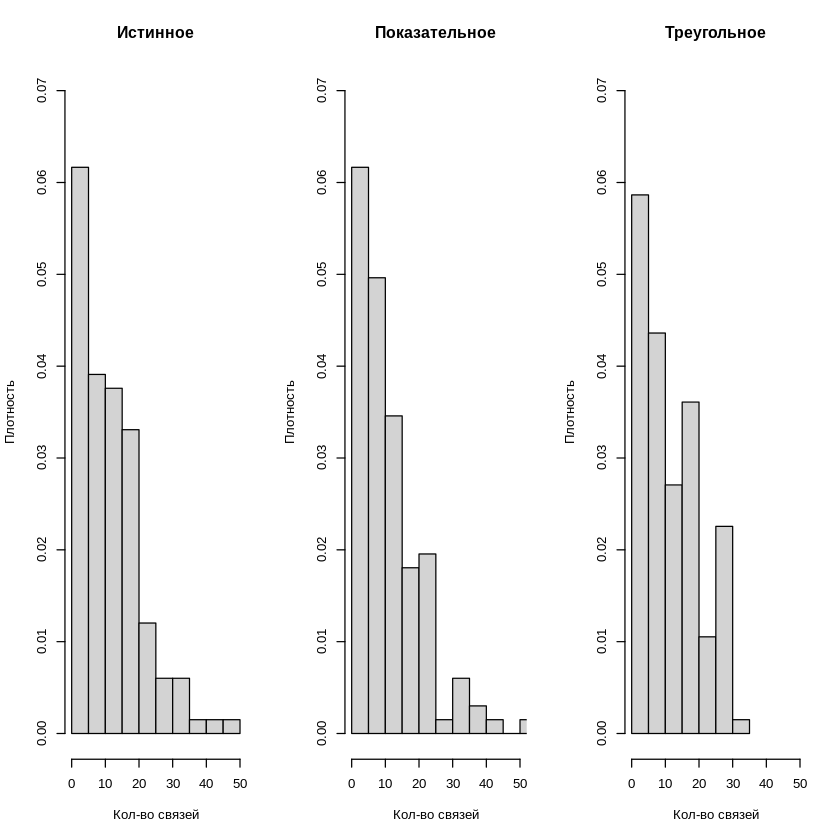

In [46]:
par(mfrow = c(1, 3))

p111 <- degree(g)
p122 <- round(rexp(gorder(g),1/mean(degree(g))))
p133 <- round(rtri(gorder(g), max = mean(degree(g))*3))


#xlim = c(4, 5.4), breaks = 100)
p11<-hist(p111, xlim = c(0, 50),ylim=c(0,0.07),breaks = 10,freq = FALSE,xlab = "Кол-во связей", ylab = "Плотность",main = "Истинное")
#lines(density(p111, bw = bw.SJ(p111)), lwd = 2, col = 'red')
#lines(exp(), bw = bw.SJ(p111)), lwd = 2, col = 'red')
p12<-hist(p122, xlim = c(0, 50),ylim=c(0,0.07),breaks = 10,freq = FALSE, xlab = "Кол-во связей", ylab = "Плотность",main = "Показательное")
#lines(density(p122), lwd = 2, col = 'red')
p13<-hist(p133, xlim = c(0, 50),ylim=c(0,0.07),breaks = 10,freq = FALSE, xlab = "Кол-во связей", ylab = "Плотность", main = "Треугольное")
#lines(density(p133), lwd = 2, col = 'red')


In [47]:
wilcox.test(p111,p122)[3]>0.05
wilcox.test(p111,p133)[3]>0.05

chisq.test(p111,p122,simulate.p.value = TRUE)[3]>0.05
chisq.test(p111,p133,simulate.p.value = TRUE)[3]>0.05

kruskal.test(p111,p122)[3]>0.05
kruskal.test(p111,p133)[3]>0.05

p.value 
   TRUE

p.value 
   TRUE

p.value 
   TRUE

p.value 
   TRUE

p.value 
   TRUE

p.value 
   TRUE

И вот тут из-за распутья стал тяжелый выбор. Какое распределение взять? Треугольное или показательное?

В чем разница?

В том, чтобы найти нижнюю границу для минимального количества связей реценезнта по критерию уровня значимости. Скажем при $
\alpha=0.05$ все связи что по номеру будут ниже определенного номера слишком малыми.

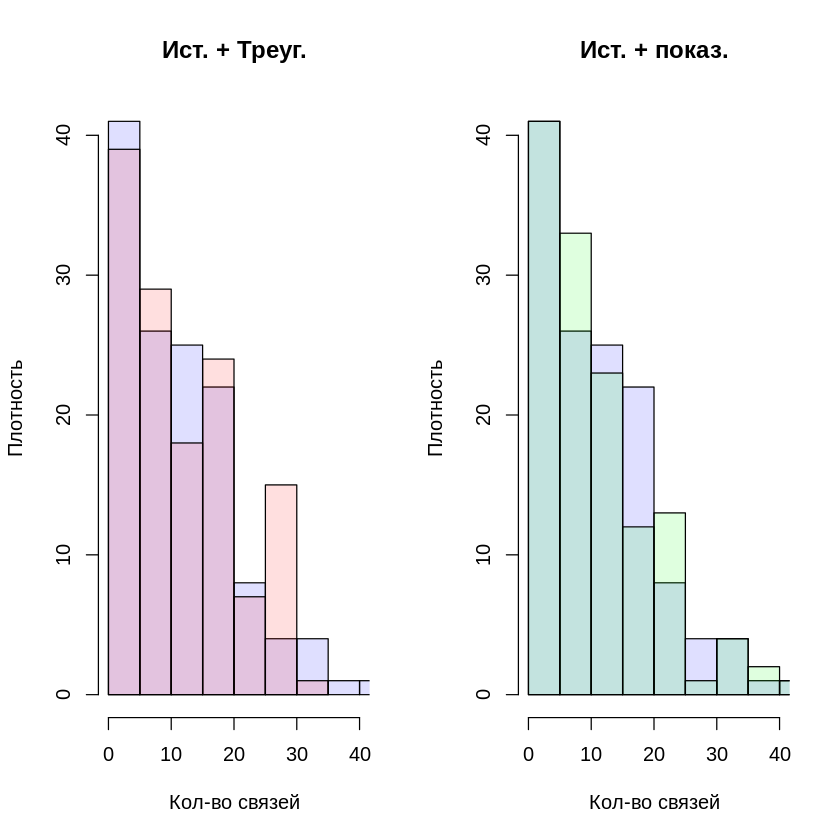

In [48]:
par(mfrow = c(1, 2))

plot( p11, col=rgb(0,0,1,1/8), xlim=c(0,40),xlab = "Кол-во связей", ylab = "Плотность", main = "Ист. + Треуг.")
plot( p13, col=rgb(1,0,0,1/8), xlim=c(0,40), add=T)
plot( p11, col=rgb(0,0,1,1/8), xlim=c(0,40), xlab = "Кол-во связей", ylab = "Плотность",main = "Ист. + показ.")
plot( p12, col=rgb(0,1,0,1/8), xlim=c(0,40), add=T)

Но в конечном счёте нам нужно определить сколько статистически минимальное количество связей создается рецензентом в редакционной коллегии журнала. Попробуем оценить это двумя способами и найдем это минимальное количество связей.

Гипотеза простая. Пусть существует такое количество связей $N$ при котором уровень значимости меньше $0.05$.

Для показательного распределения это может быть записано в виде

$$
\int\limits_{0}^{\max(N)}  \lambda \exp(-x\lambda)dx \leqslant 0.05
$$
Для правотреугольного соотверственно
$$
\int\limits_{0}^{\max(N)} \frac{2(b-x)}{b^2}dx\leqslant0.05
$$



Очевидно, что чем большее количество связей создают рецензенты между друг другом, тем более вытянутое будет распределение (и показательное и треугольное).

Однако для любого распределения существует отсечка по рецензентам, которые не дотягивают до статистически минимального уровня по количеству связей и их можно исключить.

Оценим вероятность что рецензента с одной связью можно исключить.

Например, вероятность что рецензент с одной связью при среднем значении количества связей по показательному распределению будет

In [49]:
pexp(1,rate=1/mean(degree(g)))<0.05

[1] FALSE

То есть больше чем уровень значимости и его нельзя списывать со счетов даже при наличии одной связи с другами членами редакционной коллегии.

Например, вероятность что рецензент с одной связью при среднем значении количества связей по треугольному распределению будет

In [51]:
ptri(1,max=3*mean(degree(g)))<0.05

[1] TRUE

То есть уже меньше, чем уровень значимости и можно списывать со счетов даже при наличии одной связи с другами членами редакционной коллегии.

Получается в завимости от выбраннного распределения показательного или треугольного либо можно, либо нельзя списывать со счётов рецензента с одной связью в редакционной коллегии.

Найдем такое среднее количество связей рецензентов, при котором можно списыть рецензента с одной двумя и даже тремя созданными связями.

Воспользуемся поиском первого отрицательного элемента, который в распределении меньше $0.05$

In [52]:
time <- seq(1, 200, by = 1)
relation_e_1 <- pexp(1,rate=1/time)-0.05
relation_e_2 <- pexp(2,rate=1/time)-0.05
relation_e_3 <- pexp(3,rate=1/time)-0.05

relation_t_1 <- ptri(1,max=time*3)-0.05
relation_t_2 <- ptri(2,max=time*3)-0.05
relation_t_3 <- ptri(3,max=time*3)-0.05

print("Показательное")
which(relation_e_1 <= 0)[1]
which(relation_e_2 <= 0)[1]
which(relation_e_3 <= 0)[1]

print("Треугольное")
which(relation_t_1 <= 0)[1]
which(relation_t_2 <= 0)[1]
which(relation_t_3 <= 0)[1]

[1] "Показательное"


[1] 20

[1] 39

[1] 59

[1] "Треугольное"


[1] 10

[1] 24

[1] 37

Таблица среднего количества связей рецензентов при котором можно списать рецензента с малым количеством связей.

| Кол-во связей | Эксп. | Треугл. |
|:---:|:---:|:----:|
|1|20|**10**|
|2|39|24|
|3|59|37|


### Построение связей рецензента

В [проекте](https://github.com/denisbolshakoff/analysis_text_corpus_project) использовались тексты опубликованных и неопубликованных статей для распознования рецензента. Однако если модель выдает список рецензентов и все из них заняты. Что делать? В этом нам помогут нижеприведенные методы построения остовного дерева.

Допустим модель выдала рецензентов 1,2,9,10,11 и 13 и все они оказались заняты. Кого же тогда выбрать вместо них? Это легко сделать зная связи рецензентов с другими.

Просто построим граф остовного дерева связей рецензентов за все годы из графа ближайщих соседей.

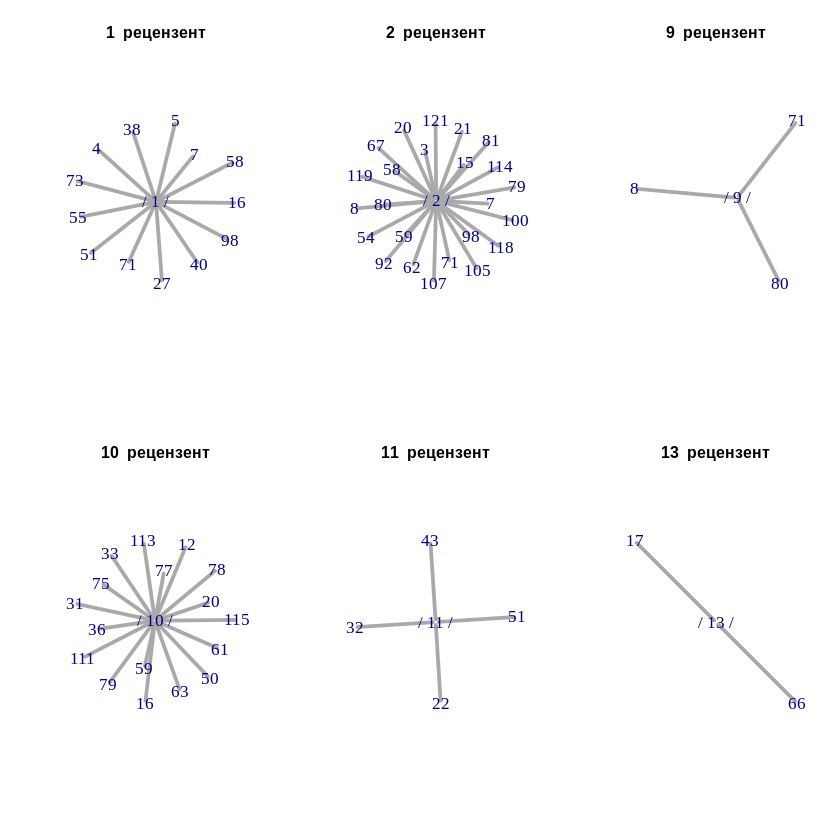

In [53]:
par(mfrow=c(2,3))

invisible(lapply(c(1,2,9,10,11,13),spanning_tree_graph))

Получились графы остовного дерера из графа ближайших соседей.

Это позволит нам найти рецензента если центральный рецензент занят, в командировке  или не доступен по другим причинам.

Нам бы в целом хватило и нижеприведенной информации, где первое число, номер рецензента. а остальные рецензенты, что с ним связаны.

In [54]:
c(117, neighbors(g, 117))

[1] 117   4  14  16  18  20  33  79 100 103 107

## Выводы

1. Граф связей редакционной коллегии:
    * Связан большую часть эволюции;
    * Имеет:
        * диаметр соответствующий гипотезе шести рукожатий;
        *  распределение степени вершин близкое к треугольному или показательному;
        * нормальное распределение длин путей между вершинами;
        * линейно возрастающее среднее количество связей между рецензентами при эволюции, но остающиеся примерно на порядок меньше максимального количества связей полного графа.
2. Можно найти замену рецензенту его по остовному дереву графа ближайщих соседей.
3. Вопрос исключения из редакционной коллегии рецензентов с малым количеством связей дискуссионый и зависит от выбранного способа оценки получаемого распределения.